# 🧪 Data Preprocessing Lab – Sales Dataset
**Course:** Data Science Foundations | **Level:** Undergraduate / Graduate

---
## Lab Objectives
By the end of this lab you will be able to:
- Detect and handle missing values, duplicates, and invalid entries
- Standardize messy text and date fields
- Detect and treat outliers using IQR and Z-score methods
- Apply transformations, encoding, and feature engineering
- Validate data quality and visualize distributions

**Dataset:** `Sales_Preprocessing.xlsx` — a realistic but intentionally messy sales ledger.

> 💡 **Instructor note:** Each section ends with a `# TRY:` comment — encourage students to experiment.


---
## 0. Setup — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('Libraries loaded ✅')

Libraries loaded ✅


---
## 1. Data Understanding

In [ ]:
# ── Load dataset
df = pd.read_excel('Sales_Preprocessing.xlsx', sheet_name='Sales_Data')

print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print()
df.head(10)

Shape: 265 rows × 12 columns



,Order_ID,Order_Date,Customer_Name,Region,Product_Category,Product_Name,Quantity,Unit_Price,Total_Sales,Discount,Profit,Customer_Email
0,ORD-10026,17 Aug 2023,Robert Jackson,South,Furniture,Sofa Set,18.00,1500.00,20250.00,0.25,2858.54,robertjackson28@yahoo.com
1,ORD-10054,20 Jul 2023,Emma Garcia,WEST,Sports,Tennis Racket,16.00,130.00,1539.20,0.26,283.16,emmagarcia31@yahoo.com
2,ORD-10049,2023-05-19,Robert Anderson,Cenral,Groceries,Greek Yogurt,15.00,3.00,32.85,0.27,3.43,robertanderson@outlook.com
3,ORD-10092,03 Jun 2022,Michael Brown,North,Clothing,Cotton T-Shirt,15.00,30.00,369.00,0.18,118.73,michael.brown@outlook.com
4,ORD-10150,20/04/2022,Sarah Davis,Cenral,Furniture,Bookshelf,8.00,250.00,1560.00,0.22,310.04,sarahdavis49@hotmail.com
5,ORD-10003,09/01/2023,John White,west,Furniture,Office Chair,8.00,400.00,2368.00,0.26,388.44,johnwhite@company.com
6,ORD-10082,09 Oct 2022,John Jones,West,Sports,Dumbbell Set,11.00,200.00,2090.00,0.05,147.32,john_jones@outlook.com
7,ORD-10223,23 Jan 2022,Sarah Thomas,South,Clothing,Running Shoes,13.00,120.00,1544.40,0.01,181.15,sarahthomas5@outlook.com
8,ORD-10236,18/09/2023,Maria Jones,West,Furniture,Office Chair,2.00,400.00,584.00,NaN,NaN,NaN
9,ORD-10121,"June 29, 2022",Daniel Harris,north,Electronics,Laptop Pro,19.00,1200.00,21204.00,0.07,5759.13,daniel.harris51@yahoo.com


In [ ]:
# ── Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          265 non-null    object 
 1   Order_Date        265 non-null    object 
 2   Customer_Name     254 non-null    object 
 3   Region            252 non-null    object 
 4   Product_Category  256 non-null    object 
 5   Product_Name      265 non-null    object 
 6   Quantity          256 non-null    float64
 7   Unit_Price        265 non-null    float64
 8   Total_Sales       265 non-null    float64
 9   Discount          248 non-null    float64
 10  Profit            245 non-null    float64
 11  Customer_Email    234 non-null    object 
dtypes: float64(5), object(7)
memory usage: 25.0+ KB


In [ ]:
# ── Summary statistics
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_ID,265,250,ORD-10121,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,265,241,"June 29, 2022",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Name,254,167,David Anderson,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,252,26,EAST,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Category,256,22,Electronics,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Name,265,25,Greek Yogurt,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,256.00,NaN,NaN,NaN,12.46,31.14,-5.00,5.00,11.00,15.00,500.00
Unit_Price,265.00,NaN,NaN,NaN,1098.58,6079.89,-99.00,30.00,180.00,600.00,50000.00
Total_Sales,265.00,NaN,NaN,NaN,5256.76,15581.70,-200.00,252.00,1078.00,3888.00,150000.00
Discount,248.00,NaN,NaN,NaN,0.15,0.09,0.00,0.08,0.15,0.23,0.30


In [ ]:
# ── Unique values per column
for col in df.columns:
    uq = df[col].nunique(dropna=False)
    print(f'{col:<22} unique={uq:>4}  | sample: {df[col].dropna().unique()[:4]}')

Order_ID               unique= 250  | sample: ['ORD-10026' 'ORD-10054' 'ORD-10049' 'ORD-10092']
Order_Date             unique= 241  | sample: ['17 Aug 2023' '20 Jul 2023' '2023-05-19' '03 Jun 2022']
Customer_Name          unique= 168  | sample: ['Robert Jackson' 'Emma Garcia' 'Robert Anderson' 'Michael Brown']
Region                 unique=  27  | sample: ['South ' 'WEST' 'Cenral' '  North']
Product_Category       unique=  23  | sample: ['Furniture' 'Sports' 'Groceries' 'Clothing']
Product_Name           unique=  25  | sample: ['Sofa Set' 'Tennis Racket' 'Greek Yogurt' 'Cotton T-Shirt']
Quantity               unique=  24  | sample: [18. 16. 15.  8.]
Unit_Price             unique=  28  | sample: [1500.  130.    3.   30.]
Total_Sales            unique= 240  | sample: [20250.    1539.2     32.85   369.  ]
Discount               unique=  32  | sample: [0.25 0.26 0.27 0.18]
Profit                 unique= 232  | sample: [2858.54  283.16    3.43  118.73]
Customer_Email         unique= 216  | 

> **Observation prompts:**
> - Which columns have far more unique values than expected?
> - Which numeric columns show suspicious min/max values?
> - Are the data types inferred correctly?

---
## 2. Missing Value Handling

In [ ]:
# ── Count and percentage of missing values
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %':     (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing %', ascending=False)

missing[missing['Missing Count'] > 0]

,Missing Count,Missing %
Customer_Email,31,11.70
Profit,20,7.55
Discount,17,6.42
Region,13,4.91
Customer_Name,11,4.15
Product_Category,9,3.40
Quantity,9,3.40


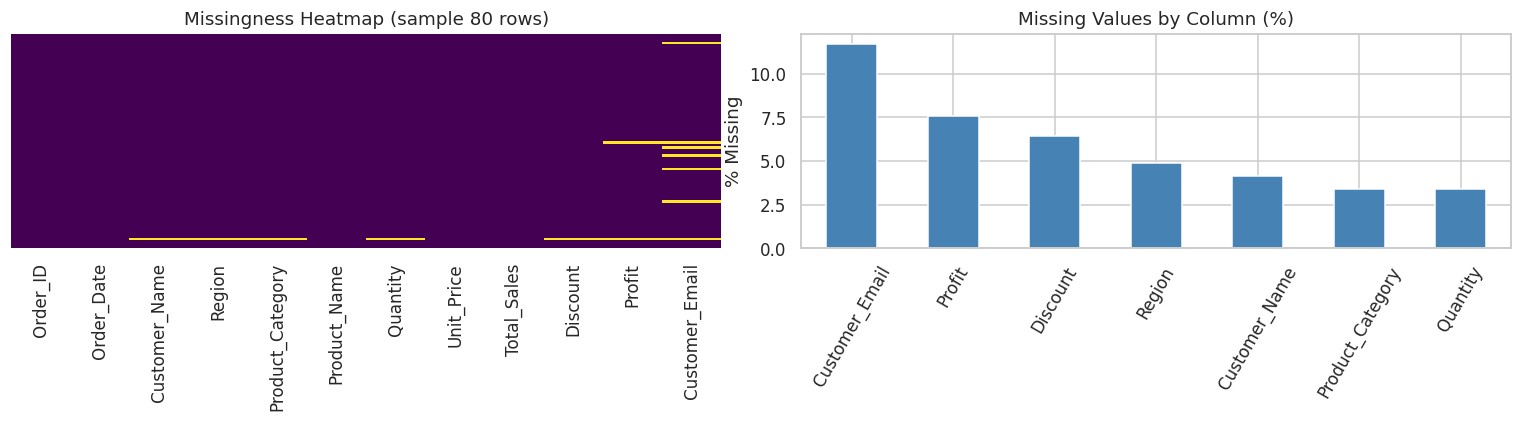

In [ ]:
# ── Visualise missingness as heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap of nulls (sample 80 rows for readability)
sns.heatmap(df.sample(80, random_state=1).isnull(),
            cbar=False, yticklabels=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Missingness Heatmap (sample 80 rows)')

# Bar chart of missing %
missing_cols = missing[missing['Missing Count'] > 0]
missing_cols['Missing %'].plot(kind='bar', color='steelblue', ax=axes[1])
axes[1].set_title('Missing Values by Column (%)')
axes[1].set_ylabel('% Missing')
axes[1].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()

In [ ]:
# ── Strategy 1: Median imputation for Quantity
# Use median (robust to outliers) for skewed numeric columns
qty_median = df['Quantity'].median()
df['Quantity'] = df['Quantity'].fillna(qty_median)
print(f'Quantity median fill: {qty_median}')

Quantity median fill: 11.0


In [ ]:
# ── Strategy 2: Mean imputation for Discount
# Discount is roughly symmetric — mean is acceptable
disc_mean = df['Discount'].mean()
df['Discount'] = df['Discount'].fillna(disc_mean)
print(f'Discount mean fill:   {disc_mean:.4f}')

Discount mean fill:   0.1505


In [ ]:
# ── Strategy 3: Median imputation for Profit
df['Profit'] = df['Profit'].fillna(df['Profit'].median())

In [ ]:
# ── Strategy 4: Mode imputation for Region ───────────────────────────────────
# We'll fix Region text first (Section 4), then impute missing ones
# For now, fill with placeholder so we don't lose rows
df['Region'] = df['Region'].fillna('Unknown')

In [ ]:
# ── Strategy 5: Drop rows where Customer_Name is missing
# Name is non-recoverable; row count impact is small (~4%)
before = len(df)
df.dropna(subset=['Customer_Name'], inplace =True)
print(f'Dropped {before - len(df)} rows with missing Customer_Name')

Dropped 11 rows with missing Customer_Name


In [ ]:
# ── Strategy 6: Mark invalid emails as NaN for later handling
# (handled in Section 4 – Data Cleaning)

In [ ]:
# ── Strategy 7: Forward-fill Product_Category (sorted by Order_ID)
df = df.sort_values('Order_ID').reset_index(drop=True)
df['Product_Category'] = df['Product_Category'].fillna(method='ffill')

print(f'\nRemaining nulls:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

# TRY: Replace median imputation with KNN imputation from sklearn.impute.KNNImputer


Remaining nulls:
Customer_Email    20
dtype: int64


---
## 3. Duplicate Handling

In [ ]:
# ── Detect duplicates
n_dups = df.duplicated().sum()
print(f'Exact duplicate rows: {n_dups}')
df[df.duplicated(keep=False)].sort_values('Order_ID').head(10)

Exact duplicate rows: 14


,Order_ID,Order_Date,Customer_Name,Region,Product_Category,Product_Name,Quantity,Unit_Price,Total_Sales,Discount,Profit,Customer_Email
3,ORD-10003,09/01/2023,John White,west,Furniture,Office Chair,8.00,400.00,2368.00,0.26,388.44,johnwhite@company.com
4,ORD-10003,09/01/2023,John White,west,Furniture,Office Chair,8.00,400.00,2368.00,0.26,388.44,johnwhite@company.com
78,ORD-10080,15 Feb 2023,Robert Taylor,SOUTH,Sports,Cycling Helmet,12.00,0.01,989.40,0.03,300.13,robert.taylor@company.com
79,ORD-10080,15 Feb 2023,Robert Taylor,SOUTH,Sports,Cycling Helmet,12.00,0.01,989.40,0.03,300.13,robert.taylor@company.com
83,ORD-10084,2022-06-26,William Anderson,North,Electronics,Tablet Air,4.00,600.00,1824.00,0.24,549.41,williamanderson@outlook.com
84,ORD-10084,2022-06-26,William Anderson,North,Electronics,Tablet Air,4.00,600.00,1824.00,0.24,549.41,williamanderson@outlook.com
86,ORD-10086,2023-12-27,David Taylor,West,Clothing,Denim Jeans,10.00,70.00,497.00,0.29,128.99,david_taylor@hotmail.com
87,ORD-10086,2023-12-27,David Taylor,West,Clothing,Denim Jeans,10.00,70.00,497.00,0.29,128.99,david_taylor@hotmail.com
95,ORD-10094,04 Jun 2023,William Wilson,Central,Clothing,Winter Jacket,17.00,180.00,2172.60,0.29,152.74,william_wilson@outlook.com
96,ORD-10094,04 Jun 2023,William Wilson,Central,Clothing,Winter Jacket,17.00,180.00,2172.60,0.29,152.74,william_wilson@outlook.com


In [ ]:
# ── Remove duplicates
# keep='first' — retains first occurrence
df.drop_duplicates(keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Shape after dedup: {df.shape}')

# ── Check for duplicate Order_IDs (logical duplicates)
dup_ids = df[df.duplicated(subset=['Order_ID'], keep=False)]
print(f'Rows with duplicate Order_ID (non-exact): {len(dup_ids)}')

# NOTE: In real business data, duplicate Order_IDs may indicate split shipments,
# not errors. Always investigate context before dropping.

Shape after dedup: (240, 12)
Rows with duplicate Order_ID (non-exact): 0


---
## 4. Data Cleaning

In [ ]:
# ── 4a. Trim extra whitespace from all string columns
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda c: c.str.strip())
print('Whitespace trimmed')

Whitespace trimmed


In [ ]:
# ── 4b. Standardise Region labels
print('Region unique (before):', sorted(df['Region'].dropna().unique()))

# Title-case, then map known variants
df['Region'] = df['Region'].str.strip().str.title()

region_map = {
    'Nrth':    'North',
    'Sourth':  'South',
    'Esat':    'East',
    'Westt':   'West',
    'Cenral':  'Central',
    'Centre':  'Central',
    'Unknown': 'Unknown',   # keep placeholder
}
df['Region'] = df['Region'].replace(region_map)

# Impute 'Unknown' with mode now that variants are clean
mode_region = df[df['Region'] != 'Unknown']['Region'].mode()[0]
df['Region'] = df['Region'].replace('Unknown', mode_region)

print('Region unique (after): ', sorted(df['Region'].unique()))

Region unique (before): ['CENTRAL', 'Cenral', 'Central', 'Centre', 'EAST', 'East', 'Esat', 'NORTH', 'North', 'Nrth', 'SOUTH', 'Sourth', 'South', 'Unknown', 'WEST', 'West', 'Westt', 'central', 'east', 'north', 'south', 'west']
Region unique (after):  ['Central', 'East', 'North', 'South', 'West']


In [ ]:
df.head(45)

,Order_ID,Order_Date,Customer_Name,Region,Product_Category,Product_Name,Quantity,Unit_Price,Total_Sales,Discount,Profit,Customer_Email
0,ORD-10000,2023-07-13,John Thomas,North,electronics,Laptop Pro,9.00,1200.00,10044.00,0.07,922.66,john.thomas@company.com
1,ORD-10001,"June 13, 2022",Christopher Jackson,North,Sports,Cycling Helmet,8.00,85.00,591.60,0.13,78.95,christopher_jackson@hotmail.com
2,ORD-10002,2023-01-23,Maria Harris,Central,Furniture,Coffee Table,9.00,300.00,2052.00,0.24,551.82,@gmail.com
3,ORD-10003,09/01/2023,John White,West,Furniture,Office Chair,8.00,400.00,2368.00,0.26,388.44,johnwhite@company.com
4,ORD-10004,2022-11-29,Sarah Anderson,Central,Sports,Resistance Bands,6.00,50000.00,129.00,0.14,16.90,sarah_anderson@yahoo.com
5,ORD-10005,23/05/2022,David Jones,West,Sports,Dumbbell Set,7.00,200.00,1120.00,0.20,188.93,davidjones55@outlook.com
6,ORD-10007,22/03/2023,Maria Jones,East,Electronics,Laptop Pro,18.00,1200.00,16632.00,0.23,4666.60,maria.jones@outlook.com
7,ORD-10008,2023-06-28,Christopher Harris,Central,Sports,Tennis Racket,7.00,130.00,864.50,0.05,240.98,christopher_harris@yahoo.com
8,ORD-10010,2023-04-08,Daniel Wilson,West,Clothing,Denim Jeans,13.00,70.00,637.00,0.30,156.04,danielwilson@company.com
9,ORD-10011,09-01-2022,Maria Wilson,East,Electronics,Laptop Pro,8.00,1200.00,9408.00,0.02,559.06,mariawilson74@yahoo.com


In [ ]:
# ── 4c. Standardise Product_Category
df['Product_Category'] = df['Product_Category'].str.strip().str.title()
print('Category unique:', sorted(df['Product_Category'].dropna().unique()))

# TRY: Use thefuzz (pip install thefuzz) for fuzzy matching when there are many variants

Category unique: ['Clothing', 'Electronics', 'Furniture', 'Groceries', 'Sports']


In [ ]:
# ── 4d. Standardise Customer_Name to Proper Case
df['Customer_Name'] = df['Customer_Name'].str.strip().str.title()
# Collapse multiple spaces
df['Customer_Name'] = df['Customer_Name'].str.replace(r'\s+', ' ', regex=True)
print('Sample names:', df['Customer_Name'].unique()[:8])

Sample names: ['John Thomas' 'Christopher Jackson' 'Maria Harris' 'John White'
 'Sarah Anderson' 'David Jones' 'Maria Jones' 'Christopher Harris']


In [ ]:
# ── 4e. Validate and clean Customer_Email
import re

EMAIL_RE = re.compile(r'^[\w.+-]+@[\w-]+\.[a-zA-Z]{2,}$')

def is_valid_email(email):
    if pd.isna(email) or str(email).strip() == '':
        return False
    return bool(EMAIL_RE.match(str(email).strip()))

df['Email_Valid'] = df['Customer_Email'].apply(is_valid_email)
invalid_emails = df[~df['Email_Valid']]['Customer_Email'].head(8)
print(f'Invalid emails: {(~df["Email_Valid"]).sum()}')
print(invalid_emails.values)

# Set invalid emails to NaN
df.loc[~df['Email_Valid'], 'Customer_Email'] = np.nan
df.drop(columns=['Email_Valid'], inplace=True)

Invalid emails: 31
['@gmail.com' nan nan 'Robert@@hotmail.com' 'Emma@@outlook.com' nan
 '@company.com' 'not provided']


In [ ]:
# ── 4f. Fix invalid Quantity values
print(f'Quantity <= 0 before fix: {(df["Quantity"] <= 0).sum()}')

# Negative or zero quantities are invalid — replace with median
qty_med = df[df['Quantity'] > 0]['Quantity'].median()
df.loc[df['Quantity'] <= 0, 'Quantity'] = qty_med
print(f'Quantity <= 0 after fix:  {(df["Quantity"] <= 0).sum()}')

Quantity <= 0 before fix: 4
Quantity <= 0 after fix:  0


---
## 5. Date Parsing & Cleaning

In [ ]:
# ── Sample the mixed date formats
print('Raw date samples:')
print(df['Order_Date'].sample(10, random_state=5).values)

Raw date samples:
['2023-04-18' '27/07/2022' '12-22-2023' 'October 17, 2023' '2022-01-27'
 '11-27-2022' '09 Nov 2023' '07-25-2023' '04-20-2023' 'April 03, 2022']


In [ ]:
# ── Parse mixed date formats using dayfirst=False and infer_datetime_format
# pandas 2.x: use format='mixed' for heterogeneous dates
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='mixed', dayfirst=False, errors='coerce')

n_failed = df['Order_Date'].isna().sum()
print(f'Dates parsed. Unparseable rows: {n_failed}')
print(df['Order_Date'].describe())

Dates parsed. Unparseable rows: 0
count                    240
mean     2023-01-13 19:18:00
min      2022-01-02 00:00:00
25%      2022-07-04 12:00:00
50%      2023-01-16 12:00:00
75%      2023-06-28 12:00:00
max      2023-12-27 00:00:00
Name: Order_Date, dtype: object


In [ ]:
# ── Extract date components (Feature Engineering preview)
df['Order_Year']    = df['Order_Date'].dt.year
df['Order_Month']   = df['Order_Date'].dt.month
df['Order_Quarter'] = df['Order_Date'].dt.quarter
df['Order_DayName'] = df['Order_Date'].dt.day_name()

df[['Order_Date','Order_Year','Order_Month','Order_Quarter','Order_DayName']].head(5)

,Order_Date,Order_Year,Order_Month,Order_Quarter,Order_DayName
0,2023-07-13,2023,7,3,Thursday
1,2022-06-13,2022,6,2,Monday
2,2023-01-23,2023,1,1,Monday
3,2023-09-01,2023,9,3,Friday
4,2022-11-29,2022,11,4,Tuesday


---
## 6. Data Type Correction

In [ ]:
# ── Correct types explicitly
df['Quantity']   = df['Quantity'].astype(int)
df['Unit_Price'] = df['Unit_Price'].astype(float)
df['Total_Sales']= df['Total_Sales'].astype(float)
df['Discount']   = df['Discount'].astype(float)
df['Profit']     = df['Profit'].astype(float)

# Convert low-cardinality strings to category dtype (saves memory)
for col in ['Region', 'Product_Category', 'Product_Name']:
    df[col] = df[col].astype('category')

df.dtypes

---
## 7. Outlier Detection & Treatment

In [ ]:
# ── Boxplots before treatment
num_cols = ['Quantity', 'Unit_Price', 'Total_Sales', 'Profit']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
    ax.set_title(col)
    ax.set_xticks([])
plt.suptitle('Boxplots — Before Outlier Treatment', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ── IQR (Interquartile Range) method — identify bounds
def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

print('IQR Outlier Bounds:')
for col in num_cols:
    lo, hi = iqr_bounds(df[col].dropna())
    n_out  = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f'  {col:<15} lower={lo:>10.2f}  upper={hi:>10.2f}  outliers={n_out}')

In [ ]:
# ── Z-score method
print('Z-score Outliers (|z| > 3):')
for col in num_cols:
    z = np.abs(stats.zscore(df[col].dropna()))
    print(f'  {col:<15} outliers={( z > 3).sum()}')

In [ ]:
# ── Treatment: Winsorization (capping) — preferred for business data
# Capping preserves rows while constraining extreme values

def winsorize_col(series, lower_q=0.01, upper_q=0.99):
    lo = series.quantile(lower_q)
    hi = series.quantile(upper_q)
    return series.clip(lower=lo, upper=hi)

for col in ['Unit_Price', 'Total_Sales', 'Profit']:
    df[col] = winsorize_col(df[col])

# Quantity: cap at 99th percentile (extreme quantities are likely data errors)
df['Quantity'] = winsorize_col(df['Quantity'])

print('Winsorization applied')

# TRY: Use scipy.stats.mstats.winsorize for a direct implementation
# TRY: Instead of capping, try removing outlier rows and compare model impact

In [ ]:
# ── Boxplots after treatment
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightgreen'))
    ax.set_title(col)
    ax.set_xticks([])
plt.suptitle('Boxplots — After Winsorization', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

---
## 8. Feature Engineering

In [ ]:
# ── 8a. Revenue after discount
df['Revenue_After_Discount'] = df['Quantity'] * df['Unit_Price'] * (1 - df['Discount'])

# ── 8b. Profit margin
df['Profit_Margin'] = np.where(
    df['Revenue_After_Discount'] > 0,
    df['Profit'] / df['Revenue_After_Discount'],
    np.nan
)

# ── 8c. Price tier (binning Unit_Price)
df['Price_Tier'] = pd.cut(
    df['Unit_Price'],
    bins=[0, 50, 200, 600, np.inf],
    labels=['Budget', 'Mid-Range', 'Premium', 'Luxury']
)

# ── 8d. Sales performance flag
sales_median = df['Total_Sales'].median()
df['High_Value_Order'] = (df['Total_Sales'] > sales_median).astype(int)

df[['Quantity','Unit_Price','Revenue_After_Discount','Profit','Profit_Margin',
    'Price_Tier','High_Value_Order']].head(8)

---
## 9. Handling Skewness

In [ ]:
# ── Check skewness
skew_vals = df[num_cols].skew().sort_values(ascending=False)
print('Skewness (|> 1| = highly skewed):')
print(skew_vals)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for i, col in enumerate(num_cols):
    # original
    axes[0, i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'{col}\nskew={df[col].skew():.2f}')
    # log-transformed
    log_data = np.log1p(df[col].clip(lower=0))
    axes[1, i].hist(log_data.dropna(), bins=30, color='salmon', edgecolor='white')
    axes[1, i].set_title(f'log1p({col})\nskew={log_data.skew():.2f}')

axes[0, 0].set_ylabel('Original')
axes[1, 0].set_ylabel('Log-Transformed')
plt.suptitle('Distribution Before vs After Log Transformation', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ── Apply log transformation to skewed columns
# Store as new columns so originals are preserved
for col in ['Total_Sales', 'Profit', 'Revenue_After_Discount']:
    df[f'{col}_Log'] = np.log1p(df[col].clip(lower=0))

print('Log-transformed columns created')

# TRY: Compare log vs square-root vs Box-Cox transformation

---
## 10. Outlier-Free Numeric Data: Normalization & Standardization

In [ ]:
# ── Features to scale
scale_cols = ['Quantity', 'Unit_Price', 'Total_Sales', 'Profit', 'Discount']
df_scale   = df[scale_cols].copy()

# ── Min-Max Normalization → [0, 1]
mm_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(mm_scaler.fit_transform(df_scale),
                          columns=[f'{c}_MM' for c in scale_cols])

# ── Z-score Standardization → mean=0, std=1
std_scaler = StandardScaler()
df_std     = pd.DataFrame(std_scaler.fit_transform(df_scale),
                           columns=[f'{c}_Std' for c in scale_cols])

# ── Compare side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_scale[['Total_Sales','Profit']].plot(kind='hist', bins=30,
          alpha=0.6, ax=axes[0], title='Original')
df_minmax[['Total_Sales_MM','Profit_MM']].plot(kind='hist', bins=30,
           alpha=0.6, ax=axes[1], title='Min-Max Normalized')
df_std[['Total_Sales_Std','Profit_Std']].plot(kind='hist', bins=30,
        alpha=0.6, ax=axes[2], title='Z-score Standardized')

plt.suptitle('Feature Scaling Comparison', fontsize=13)
plt.tight_layout()
plt.show()

print('Min-Max range:')
print(df_minmax.describe().loc[['min','max']].round(3))
print('\nZ-score stats:')
print(df_std.describe().loc[['mean','std']].round(3))

---
## 11. Encoding Categorical Variables

In [ ]:
# ── 11a. Label Encoding — for ordinal or binary features
le = LabelEncoder()
df['Region_Label'] = le.fit_transform(df['Region'].astype(str))
print('Region label mapping:')
for code, label in enumerate(le.classes_):
    print(f'  {code} → {label}')

In [ ]:
# ── 11b. One-Hot Encoding — for nominal features
# Use drop_first=True to avoid dummy variable trap
cat_dummies = pd.get_dummies(df[['Region','Product_Category']],
                              prefix=['Reg','Cat'],
                              drop_first=True)
print('One-hot encoded columns:', cat_dummies.columns.tolist())
cat_dummies.head(3)

In [ ]:
# ── 11c. Handle rare categories (frequency < 2%)
# Demonstration with Order_DayName
freq = df['Order_DayName'].value_counts(normalize=True)
rare = freq[freq < 0.05].index
df['DayName_Grouped'] = df['Order_DayName'].apply(
    lambda x: 'Other' if x in rare else x
)
print('Day frequency after grouping:')
print(df['DayName_Grouped'].value_counts())

# TRY: Use target encoding (from category_encoders library) for high-cardinality columns

---
## 12. Multicollinearity Detection

Multicollinearity is a situation in which two or more independent (predictor) variables in a dataset are highly correlated with each other. This means they contain similar information, making it difficult for a model (especially linear regression) to determine the individual effect of each predictor on the target variable.

In [ ]:
# ── Correlation matrix
corr_cols = ['Quantity', 'Unit_Price', 'Total_Sales', 'Discount', 'Profit',
             'Revenue_After_Discount', 'Profit_Margin']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features', fontsize=13)
plt.tight_layout()
plt.show()

# High correlation (|r| > 0.85) signals multicollinearity risk
high_corr = [(c1, c2, corr_matrix.loc[c1, c2])
              for c1 in corr_cols for c2 in corr_cols
              if c1 < c2 and abs(corr_matrix.loc[c1, c2]) > 0.85]
print('\nHighly correlated pairs (|r| > 0.85):')
for c1, c2, r in high_corr:
    print(f'  {c1} ↔ {c2}  r={r:.3f}')

## # Variance Inflation Factor (VIF) analysis to quantify multicollinearity numerically

It tells you how much the variance (uncertainty) of a regression coefficient is increased because of correlations with other predictors.

In [ ]:
# Variance Inflation Factor (VIF) analysis to quantify multicollinearity numerically
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 1. Select the numeric features you want to test for multicollinearity
# (Using the features from your correlation matrix step)
vif_features = ['Quantity', 'Unit_Price', 'Total_Sales', 'Discount', 'Profit', 'Revenue_After_Discount']

# 2. Drop any remaining missing values for the calculation
df_vif = df[vif_features].dropna()

# 3. Add a constant/intercept column (required by statsmodels VIF)
X = add_constant(df_vif)

# 4. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 5. Filter out the constant row to show just your features
vif_data = vif_data[vif_data["Feature"] != 'const'].sort_values(by="VIF", ascending=False)

print("VIF Analysis Results:")
print(vif_data)

---
## 13. Data Validation

In [ ]:
# ── Range checks
checks = {
    'Discount in [0,1]':        ((df['Discount'] >= 0) & (df['Discount'] <= 1)).all(),
    'Quantity > 0':              (df['Quantity'] > 0).all(),
    'Unit_Price > 0':            (df['Unit_Price'] > 0).all(),
    'Total_Sales >= 0':          (df['Total_Sales'] >= 0).all(),
    'Region valid':              df['Region'].isin(['North','South','East','West','Central']).all(),
    'No null Order_ID':          df['Order_ID'].notnull().all(),
    'No null Order_Date':        df['Order_Date'].notnull().all(),
    'Profit_Margin in [0,1]':    ((df['Profit_Margin'].dropna() >= 0) &
                                   (df['Profit_Margin'].dropna() <= 1)).all(),
}

print('Validation Results:')
for check, result in checks.items():
    status = '✅' if result else '❌'
    print(f'  {status}  {check}')

In [ ]:
# ── Remaining missing values
remaining_null = df.isnull().sum()
remaining_null = remaining_null[remaining_null > 0]
if len(remaining_null):
    print('Columns with remaining nulls:')
    print(remaining_null)
else:
    print('No missing values remain in core columns')

---
## 14. Exploratory Visualizations

In [ ]:
# ── 14a. Distribution of Total Sales by Region
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='Region', y='Total_Sales', palette='Set2')
plt.title('Total Sales Distribution by Region')
plt.ylabel('Total Sales (USD)')
plt.tight_layout()
plt.show()

In [ ]:
monthly = df.groupby(['Order_Year', 'Order_Month'])['Total_Sales'].sum().reset_index()
monthly['Period'] = pd.to_datetime(monthly[['Order_Year','Order_Month']]
                                    .rename(columns={'Order_Year':'year', 'Order_Month':'month'})
                                    .assign(day=1))

plt.figure(figsize=(12, 4))
plt.plot(monthly['Period'], monthly['Total_Sales'], marker='o', linewidth=1.5)
plt.title('Monthly Total Sales Trend')
plt.ylabel('Total Sales (USD)')
plt.xlabel('Month')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
# ── 14c. Sales share by Product Category
cat_sales = df.groupby('Product_Category')['Total_Sales'].sum().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cat_sales.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Total Sales by Category')
axes[0].set_xlabel('USD')

cat_sales.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
               startangle=90, colors=sns.color_palette('pastel'))
axes[1].set_ylabel('')
axes[1].set_title('Sales Share by Category')

plt.tight_layout()
plt.show()

In [ ]:
# ── 14d. Profit Margin distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['Profit_Margin'].dropna(), bins=30, kde=True, color='mediumseagreen')
plt.axvline(df['Profit_Margin'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['Profit_Margin'].median(), color='blue', linestyle='--', label='Median')
plt.legend()
plt.title('Profit Margin Distribution')
plt.tight_layout()
plt.show()

In [ ]:
# ── 14e. Average Profit_Margin per Product_Category
avg_profit_margin_by_category = df.groupby('Product_Category')['Profit_Margin'].mean().sort_values(ascending=False)
display(avg_profit_margin_by_category)

In [ ]:
# ── 14f. Price Tier counts
plt.figure(figsize=(7, 4))
df['Price_Tier'].value_counts().sort_index().plot(
    kind='bar', color=['#a8d8ea','#aa96da','#fcbad3','#ffffd2'])
plt.title('Order Count by Price Tier')
plt.xlabel('Price Tier')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## 15. Export Clean Dataset

In [ ]:
# ── Save cleaned data
# Convert category dtypes back to string for Excel compatibility
df_export = df.copy()
for col in df_export.select_dtypes('category').columns:
    df_export[col] = df_export[col].astype(str)

out_path = 'sales_clean.xlsx'
df_export.to_excel(out_path, index=False, sheet_name='Cleaned_Data')
print(f'Cleaned dataset saved → {out_path}')
print(f'Final shape: {df_export.shape}')
print(f'Columns: {df_export.columns.tolist()}')

---
## 16. Lab Summary & Checklist

| Step | Technique | Status |
|------|-----------|--------|
| 1 | Data Understanding | ✅ |
| 2 | Missing Value Handling | ✅ |
| 3 | Duplicate Removal | ✅ |
| 4 | Text Cleaning & Standardization | ✅ |
| 5 | Date Parsing | ✅ |
| 6 | Data Type Correction | ✅ |
| 7 | Outlier Detection & Winsorization | ✅ |
| 8 | Feature Engineering | ✅ |
| 9 | Skewness & Log Transformation | ✅ |
| 10 | Normalization & Standardization | ✅ |
| 11 | Label & One-Hot Encoding | ✅ |
| 12 | Multicollinearity Detection | ✅ |
| 13 | Data Validation | ✅ |
| 14 | Visualization | ✅ |